# 📊 TVS Credit Collection Analytics: Predictive Risk Modeling & Insights
## Phase 1: Exploratory Data Analysis & Defaulter Prediction Pipeline

---

### 📝 Project Overview
This notebook establishes an end-to-end data science framework designed to optimize loan recovery strategies for a mid-sized Non-Banking Financial Company (NBFC) facing challenges with overdue loans. Traditional, unsegmented collection methods are often inefficient and cause customer friction. 

By leveraging machine learning and advanced behavior analytics, this pipeline accomplishes two core objectives:
1. **Predictive Risk Assessment:** Building a highly interpretable model to isolate customers likely to miss their next payment.
2. **Behavioral Insight Extraction:** Analyzing interaction logs, sentiment trends, and repayment markers to drive an automated strategy recommendation matrix.

---

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df_original=pd.read_csv(r"E:\TVS PROJECT\Analytics_loan_collection_dataset.csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [17]:
df=df_original.copy()#EDA should always be performed on copy of dataset to prevent loss/change of data in actual dataframe.


In [18]:
df.shape #gives number of rows and columns in dataset

(2000, 19)

In [19]:
df.head()# gives top 5 rows

,CustomerID,Age,Income,Location,EmploymentStatus,LoanAmount,TenureMonths,InterestRate,LoanType,MissedPayments,DelaysDays,PartialPayments,InteractionAttempts,SentimentScore,ResponseTimeHours,AppUsageFrequency,WebsiteVisits,Complaints,Target
0,CUST0001,59,1121522,Suburban,Self-Employed,985115,7,13.60,Business,3,151,2,2,-0.74,17.94,0.52,19,0,1
1,CUST0002,49,1784166,Urban,Student,717304,34,14.38,Education,2,47,1,2,-0.77,60.48,0.76,14,2,1
2,CUST0003,35,1053938,Rural,Student,889319,9,9.61,Personal,3,68,1,9,-0.90,27.38,0.33,32,0,1
3,CUST0004,63,1814021,Urban,Student,655730,6,9.20,Business,3,169,4,1,0.13,38.55,0.38,16,0,1
4,CUST0005,28,1827781,Suburban,Self-Employed,99847,24,12.87,Personal,2,118,2,0,-0.51,67.85,0.93,19,0,0


In [20]:
df.info() #gives a idea about our dataset 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           2000 non-null   object 
 1   Age                  2000 non-null   int64  
 2   Income               2000 non-null   int64  
 3   Location             2000 non-null   object 
 4   EmploymentStatus     2000 non-null   object 
 5   LoanAmount           2000 non-null   int64  
 6   TenureMonths         2000 non-null   int64  
 7   InterestRate         2000 non-null   float64
 8   LoanType             2000 non-null   object 
 9   MissedPayments       2000 non-null   int64  
 10  DelaysDays           2000 non-null   int64  
 11  PartialPayments      2000 non-null   int64  
 12  InteractionAttempts  2000 non-null   int64  
 13  SentimentScore       2000 non-null   float64
 14  ResponseTimeHours    2000 non-null   float64
 15  AppUsageFrequency    2000 non-null   f

In [21]:
df.describe().T #.T is used to transpose which helps in reading a long column list much easily

,count,mean,std,min,25%,50%,75%,max
Age,2000.0,4.251200e+01,12.620519,20.00,32.0000,43.000,5.300000e+01,65.00
Income,2000.0,1.111403e+06,505945.248632,168920.00,683243.2500,1117181.000,1.509750e+06,2009257.00
LoanAmount,2000.0,5.261852e+05,270278.039596,46270.00,295208.2500,520010.000,7.641245e+05,1015496.00
TenureMonths,2000.0,3.313450e+01,15.467871,5.00,20.0000,33.000,4.700000e+01,61.00
InterestRate,2000.0,1.056897e+01,2.484002,6.11,8.4475,10.435,1.275250e+01,15.47
MissedPayments,2000.0,1.922000e+00,1.308729,0.00,1.0000,2.000,3.000000e+00,8.00
DelaysDays,2000.0,8.735900e+01,51.914908,0.00,43.7500,86.000,1.330000e+02,179.00
PartialPayments,2000.0,9.960000e-01,0.999241,0.00,0.0000,1.000,2.000000e+00,6.00
InteractionAttempts,2000.0,4.452000e+00,2.896185,0.00,2.0000,4.000,7.000000e+00,9.00
SentimentScore,2000.0,-2.280000e-03,0.571433,-1.00,-0.5000,0.015,4.800000e-01,1.00


In [22]:
df.isnull().sum()

CustomerID             0
Age                    0
Income                 0
Location               0
EmploymentStatus       0
LoanAmount             0
TenureMonths           0
InterestRate           0
LoanType               0
MissedPayments         0
DelaysDays             0
PartialPayments        0
InteractionAttempts    0
SentimentScore         0
ResponseTimeHours      0
AppUsageFrequency      0
WebsiteVisits          0
Complaints             0
Target                 0
dtype: int64

In [23]:
df.drop(columns=['CustomerID'],inplace=True)# we dont need this in our eda


([<matplotlib.axis.XTick at 0x22918147890>,
 [Text(0, 0, 'No Default'), Text(1, 0, 'Default')])

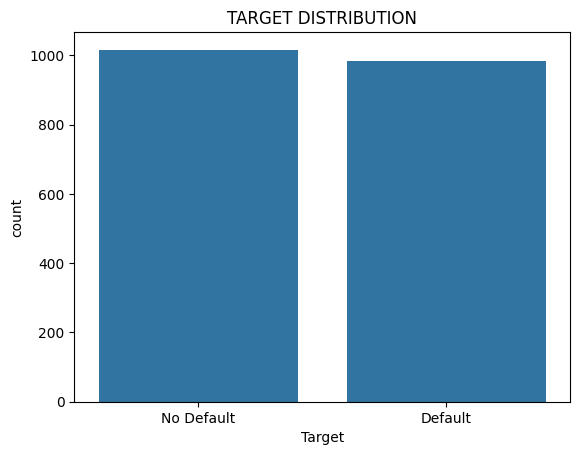

In [80]:
sns.countplot(x=df["Target"])
plt.title("TARGET DISTRIBUTION")
plt.xticks(ticks=[0,1],labels=['No Default','Default'])

In [25]:
df['Target'].value_counts()

Target
0    1016
1     984
Name: count, dtype: int64

The distribution is almost equal.


Text(0.5, 1.0, 'Location vs Default')

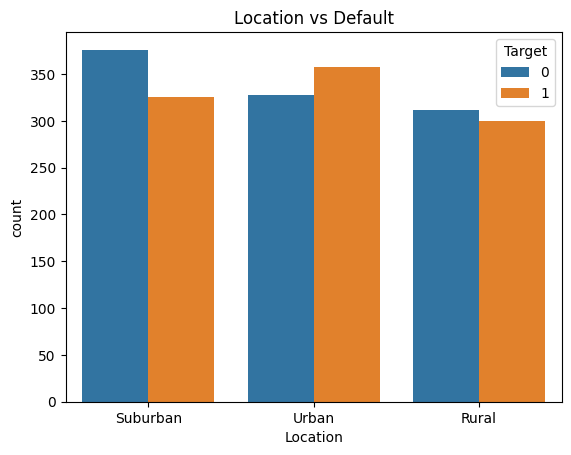

In [26]:
sns.countplot(data=df,x='Location',hue='Target')
plt.title("Location vs Default")

The ratio of defaulters to non defaulters in Urban location is much higher than that in suburban or rural areas, the same goes with total number of defaulters.This can be due to higher cost of living and financial stresses.

Text(0.5, 0, 'Income(in INR)')

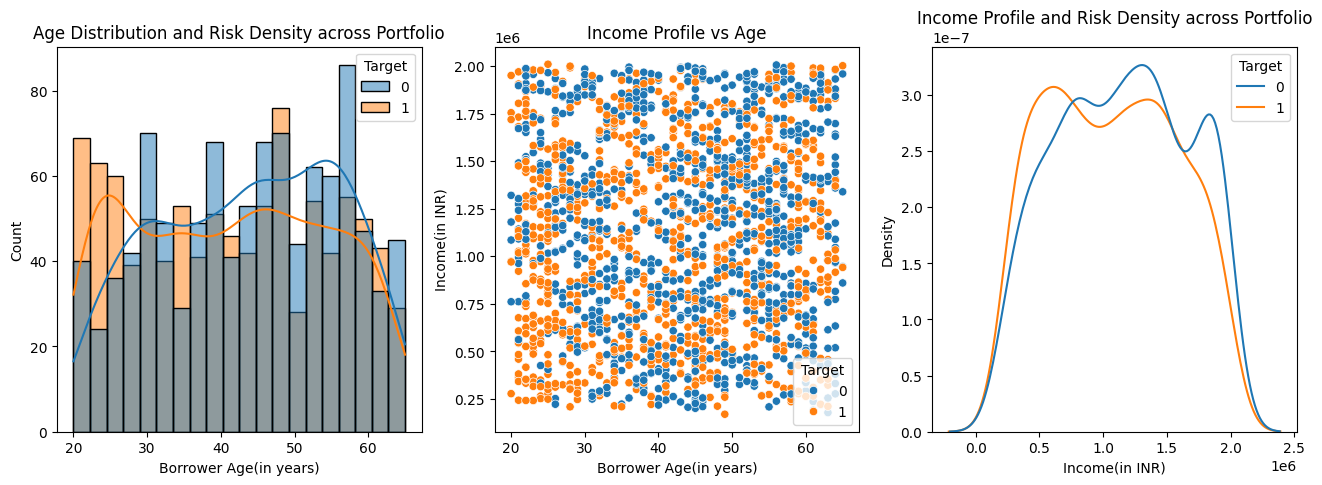

In [27]:
fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(16,5))

sns.histplot(data=df,x='Age',hue='Target',bins=20,kde=True,ax=ax[0])
sns.scatterplot(data=df,x='Age',y='Income',ax=ax[1],hue="Target")
sns.kdeplot(data=df,x='Income',hue='Target',ax=ax[2])
ax[0].set_title("Age Distribution and Risk Density across Portfolio")
ax[0].set_xlabel("Borrower Age(in years)")
ax[1].set_title("Income Profile vs Age")
ax[1].set_xlabel("Borrower Age(in years)")
ax[1].set_ylabel("Income(in INR)")
ax[2].set_title("Income Profile and Risk Density across Portfolio")
ax[2].set_xlabel("Income(in INR)")


By analyzing the distribution of borrower ages across our target variable we found some important insights:

* 1)High Risk Segment(Age 20-27):This bracket shows a heavy density of individuals missing their next payment.This may be due to entry level income profiles or high credit utilization(generally college students fall into this age bracket,and they get dependent on credits for their spends but are unable to pay back on time.)
* 2)Low Risk Segment(Age 50+): This bracket shows a heavy density of inviduals with successful repayments,indicating a reliable cash flow,strong credit stability and mature use of credits.

We can also see that people with low income are more likely to default.


Our bivariate analysis of Age vs Income shows that they are independent of each other.

Some key insights:
* 1)Low Age/High Income:According to our previous insights,higher income group is likely to repay but still young borrowers with high income defaults, this means it depends on their financial indiscipline and lack of credit knowledge in young age.
* 2)High Age/Low Income:An old borrower might have low income but is more likely to repay because they might possess financial discipline,low unwanted spending and they understand the long term financial consequences of having a low CIBIL/Credit score.

By this we learn that Age is more important factor than Income.



Text(0.5, 1.0, 'Employment Status vs Default')

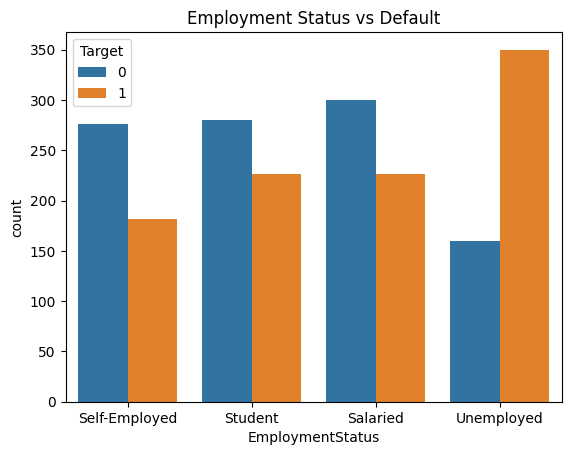

In [58]:
sns.countplot(data=df,x='EmploymentStatus',hue='Target')
plt.title("Employment Status vs Default")

Unemployed borrowers are most likely to default.

Text(0.5, 0.98, 'Loan Amount, Tenure and Interest Rate Distribution and Risk Density across Portfolio')

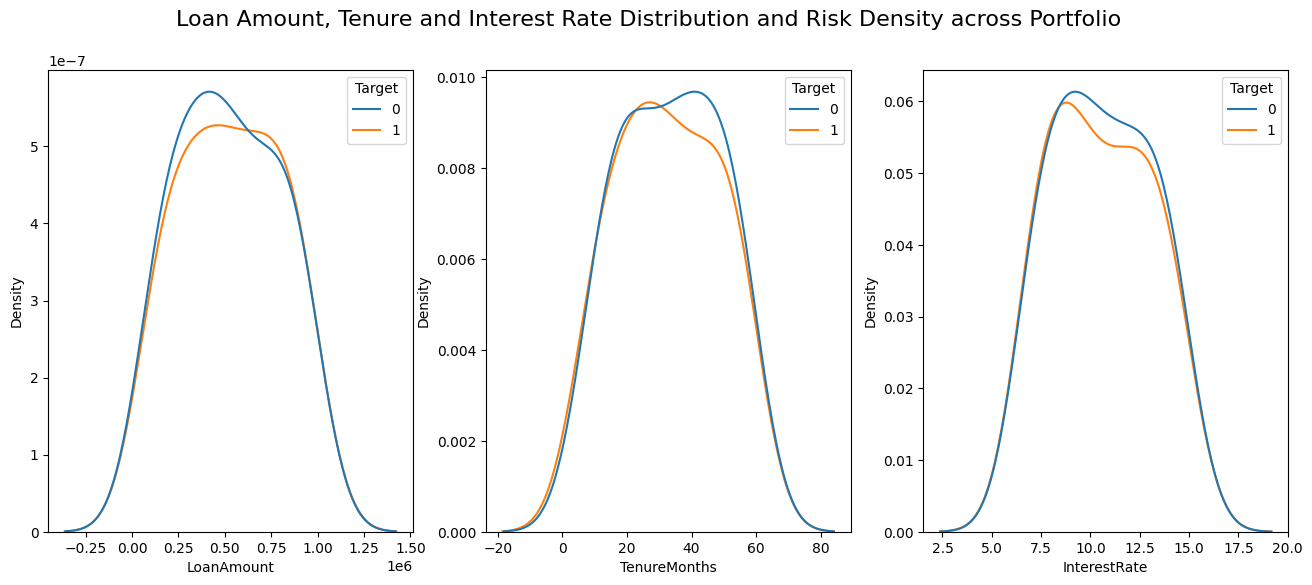

In [59]:
fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(16,6))
sns.kdeplot(data=df,x='LoanAmount',hue="Target",bw_adjust=2,ax=ax[0])
sns.kdeplot(data=df,x='TenureMonths',hue='Target',bw_adjust=2,ax=ax[1])
sns.kdeplot(data=df,x='InterestRate',hue='Target',bw_adjust=2,ax=ax[2])
plt.suptitle("Loan Amount, Tenure and Interest Rate Distribution and Risk Density across Portfolio",fontsize=16)

In [30]:
df.groupby('Target')[["LoanAmount","TenureMonths","InterestRate"]].mean()

,LoanAmount,TenureMonths,InterestRate
Target,,,
0,521315.491142,33.505906,10.600374
1,531213.333333,32.751016,10.536545


`LoanAmount`,`TenureMonths` and `InterestRate` show nearly identical probability distributions and identical group means across the `Target` groups.This indicates that our target column is independent of these 3 columns.

Text(0.5, 1.0, 'Loan Type vs Default')

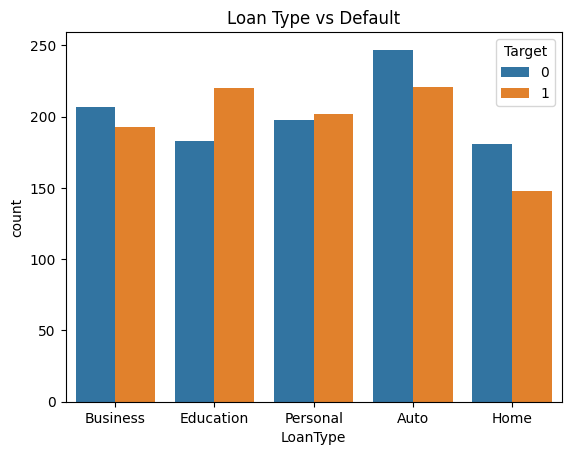

In [60]:
sns.countplot(data=df,x='LoanType',hue="Target")
plt.title("Loan Type vs Default")

This shows that Education loans are risky. These are generally taken by students and young co-applicants,but due to low initial income or unemployment after graduation they are unable to repay their loans. Also there is generally no collateral for education loan due to which the borrower doesn't feel an urgency to repay.

Text(0.5, 1.0, 'Missed Payments vs Default')

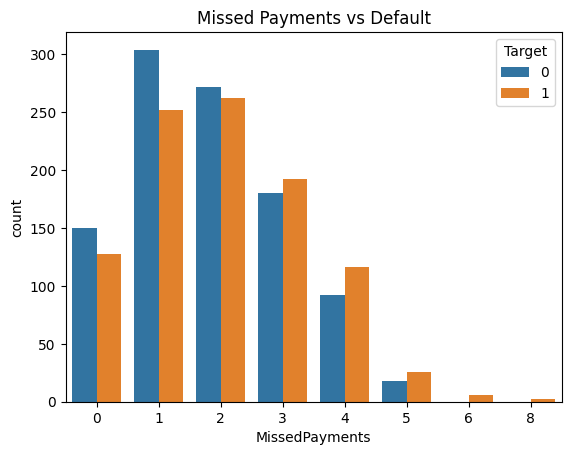

In [61]:
sns.countplot(data=df,x="MissedPayments",hue='Target')
plt.title("Missed Payments vs Default")

We can see that as the number of missed payments increases(>2),chances of default also increases.

Target
0    82.744094
1    92.123984
Name: DelaysDays, dtype: float64


Text(0.5, 1.0, 'Delays Days Distribution and Risk Density across Portfolio')

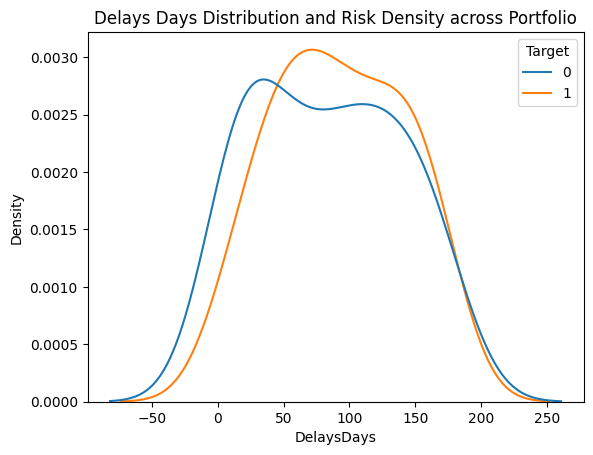

In [62]:
print(df.groupby('Target')["DelaysDays"].mean())
sns.kdeplot(data=df,x='DelaysDays',hue='Target',bw_adjust=2)
plt.title("Delays Days Distribution and Risk Density across Portfolio")


From the mean and plot we can see that customers with more delays in payments are more likely to default.

Text(0.5, 1.0, 'Partial Payments vs Default')

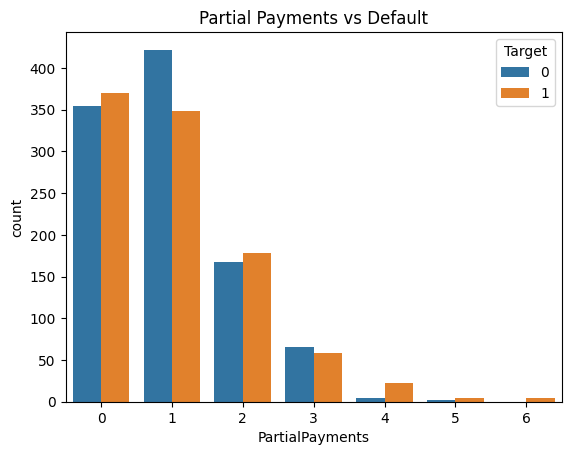

In [63]:
sns.countplot(data=df,x='PartialPayments',hue='Target')
plt.title("Partial Payments vs Default")

We can see that 1 partial payment is a common habit for borrowers which may be due to some temporary financial issue.
But higher number of partial payments is risky as it implies that the borrower doesn't have a constant cash flow or income(facing a financial struggle) and are constantly lacking the cash to clear their full dues which eventually leds to them being defaulters.

Text(0.5, 1.0, 'Interaction Attempts vs Default')

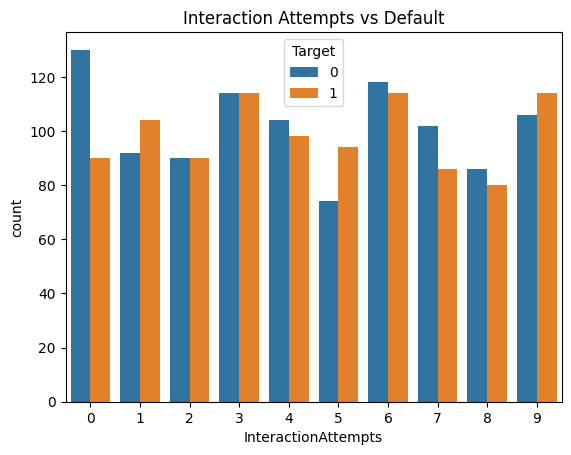

In [64]:
sns.countplot(data=df,x="InteractionAttempts",hue="Target")
plt.title("Interaction Attempts vs Default")

`InteractionAttempts` exhibits a fluctuating,non linear distribution across the target classes.
* Higher number of defaulters at some place means that the collection team is continously calling and messaging them because they are lacking behind in their payments 
* High number of interaction attempts with safe payers are due to safe,engaging communication with customer care to know their loan status,or queries resolution.


Target
0    0.034134
1   -0.039878
Name: SentimentScore, dtype: float64


Text(0.5, 1.0, 'Sentiment Score Distribution and Risk Density across Portfolio')

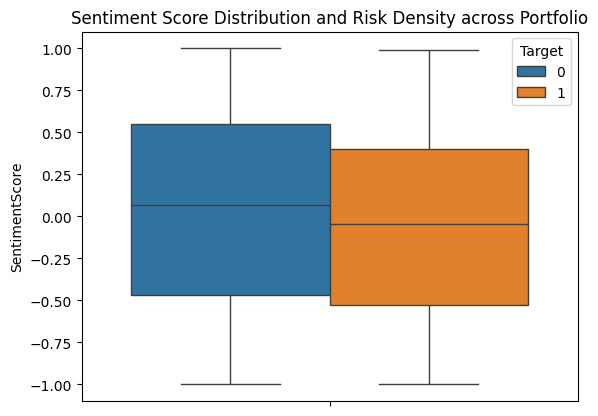

In [65]:
print(df.groupby("Target")["SentimentScore"].mean())
sns.boxplot(data=df,y="SentimentScore",hue="Target")
plt.title("Sentiment Score Distribution and Risk Density across Portfolio")


Negative sentiment score shows a slightly higher chance of being a defaulter but due the massive overlap between the interquartile ranges of the boxplot,sentiment score remains a weak standalone predictor of risk.
A negative sentiment score might be due to frustration with product or credit related issues but it does not imply that the person won't pay their dues.
In some cases sentiment score of defaulters is positive, it might be because the customer care helped them in gaining a deeper knowledge and help about how to clear their dues without feeling a pressure.

Target
0    36.011378
1    36.985528
Name: ResponseTimeHours, dtype: float64


Text(0.5, 1.0, 'Response Time Distribution and Risk Density across Portfolio')

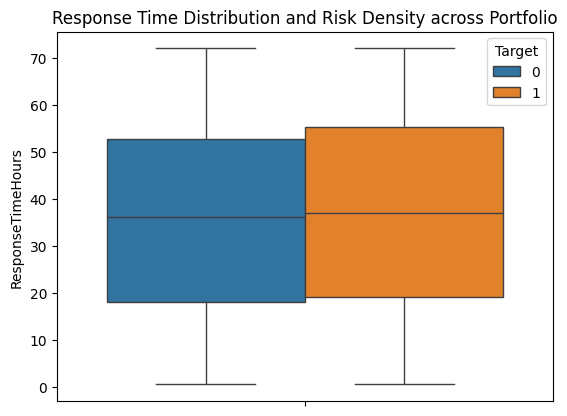

In [66]:
print(df.groupby("Target")["ResponseTimeHours"].mean())
sns.boxplot(data=df,y="ResponseTimeHours",hue="Target")
plt.title("Response Time Distribution and Risk Density across Portfolio")

Both defaulters and safe payers have similar response time hours ,which means it's effect on target column is not significant.


Target
0    0.513268
1    0.485650
Name: AppUsageFrequency, dtype: float64


Text(0.5, 1.0, 'App Usage Frequency Distribution and Risk Density across Portfolio')

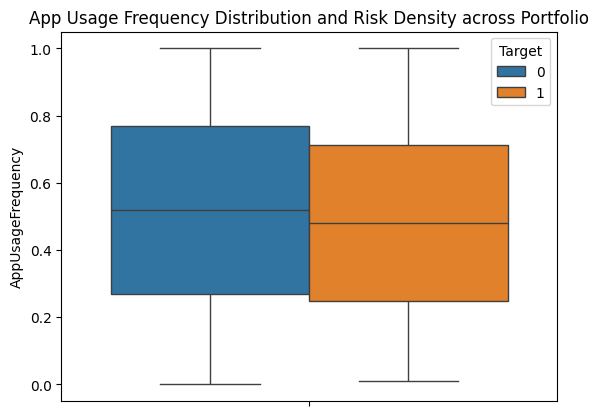

In [67]:
print(df.groupby("Target")["AppUsageFrequency"].mean())
sns.boxplot(data=df,y="AppUsageFrequency",hue="Target")
plt.title("App Usage Frequency Distribution and Risk Density across Portfolio")

Defaulters use the app a little bit lesser than safe payers.

Target
0    23.842520
1    24.065041
Name: WebsiteVisits, dtype: float64


Text(0.5, 1.0, 'Website Visits Distribution and Risk Density across Portfolio')

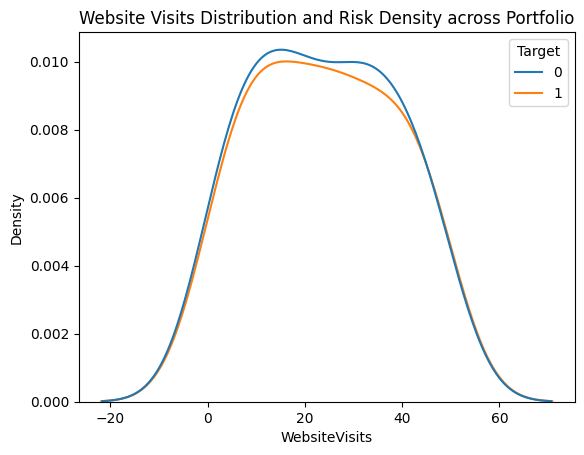

In [68]:
print(df.groupby("Target")["WebsiteVisits"].mean())
sns.kdeplot(data=df,x="WebsiteVisits",hue="Target",bw_adjust=2)
plt.title("Website Visits Distribution and Risk Density across Portfolio")

Both defaulters and safe payers visit the website almost same number of times.

Text(0.5, 1.0, 'Complaints vs Default')

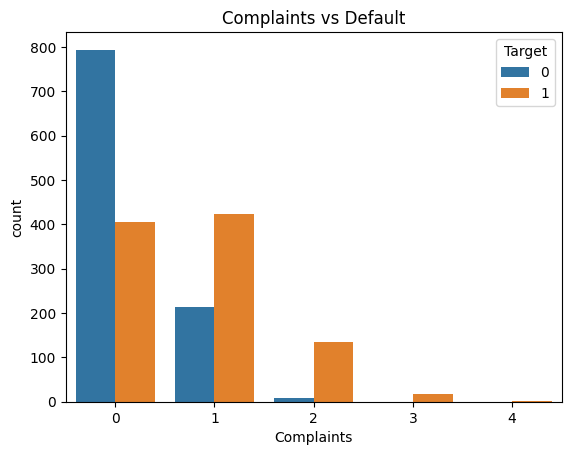

In [69]:
sns.countplot(data=df,x="Complaints",hue="Target")
plt.title("Complaints vs Default")

It is clearly evident that safe payers don't usually have any complaints(0-1) whereas the defaulters complain a lot(>=1).

Text(0.5, 1.0, 'Complaints vs Sentiment Score across Portfolio')

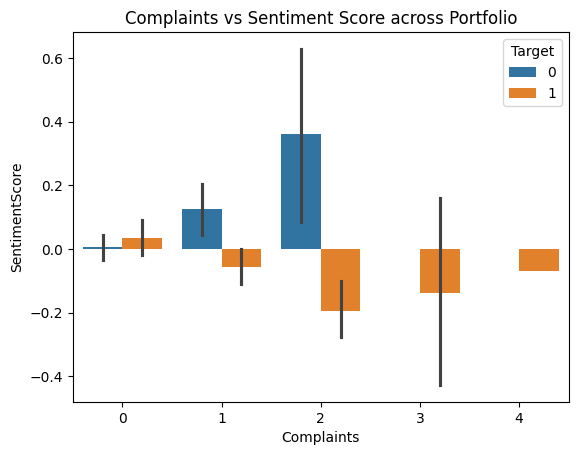

In [70]:
sns.barplot(data=df,x="Complaints",y="SentimentScore",hue="Target")
plt.title("Complaints vs Sentiment Score across Portfolio")

Plotting `Complaints` against `SentimentScore` reveals a powerful behavioral pattern between safe payers and defaulters:
As number of complaints increases ,Sentiment score of safe payers increases.This confirms our operational theory: when safe payers log complaints, customer support resolves their issues effectively, leaving them highly satisfied and collaborative.
On the other hand as number of complaint increases,Sentiment score of defaulters decreases negatively.

From this we can clearly differentiate that high number of complaints with positive sentiment score are generally safe payers and high number of complaints with negative sentiment score are defaulters.

Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

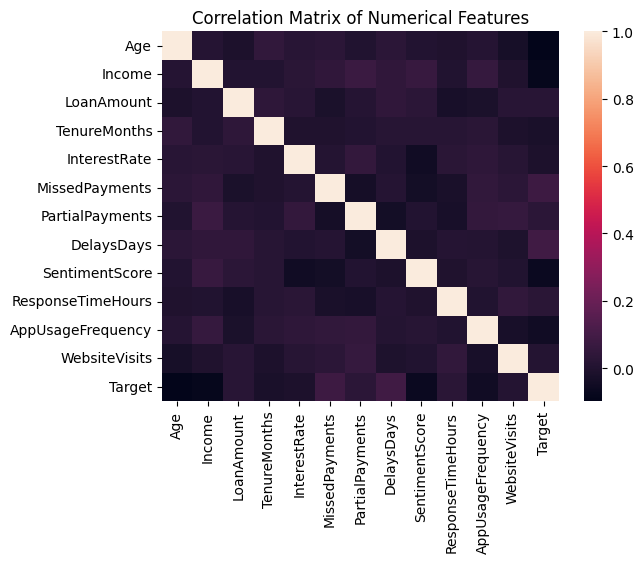

In [71]:
numerical_cols = [
    'Age', 'Income', 'LoanAmount', 'TenureMonths', 'InterestRate',
    'MissedPayments', 'PartialPayments', 'DelaysDays', 'SentimentScore', 
    'ResponseTimeHours', 'AppUsageFrequency', 'WebsiteVisits', 'Target'
]

num_corr = df[numerical_cols].corr()
sns.heatmap(num_corr )
plt.title("Correlation Matrix of Numerical Features")


### Key Takeaways from the Correlation Heatmap

* Zero Redundancy (No Multicollinearity):Aside from the self-matching diagonal line, the entire map is dark. This proves our columns are completely independent and don't contain overlapping information, which keeps our model stable.
* Hidden, Non-Linear Patterns:The bottom `Target` row looks weakly correlated because standard heatmaps only catch smooth, straight-line relationships. 

---

## Phase 2: Feature Engineering Pipeline

In this phase, we convert the deep behavioral boundaries and structural insights identified during our exploratory analysis into high-signal feature matrices optimized for our models.

### 1. Transforming Age into Non-Linear Risk Buckets (`Age_Risk_Group`)

**Reasoning:** Our bivariate density analysis exposed a structural "Youth Risk Wall" below the age of 30, where borrowers default at significantly higher frequencies regardless of their individual income levels,whereas senior citizens above 50 are generally safe payers. Because standard linear scales do not understand this sharp cliff, we create explicit categorical buckets to allow our model to isolate the youth risk segment cleanly.

Text(0.5, 1.0, 'Age Risk Group vs Default')

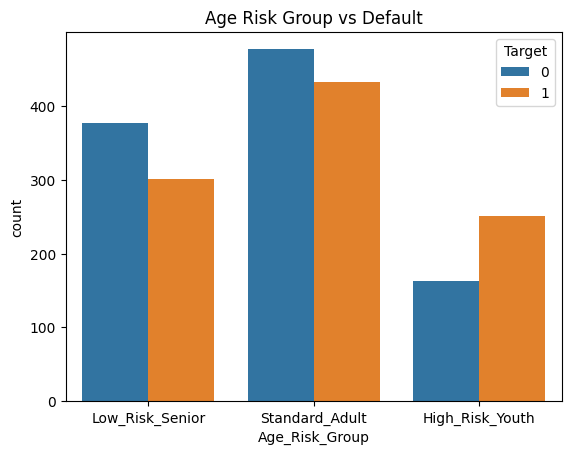

In [72]:
age_conditions = [
    (df['Age'] < 30),
    (df['Age'] >= 30) & (df['Age'] < 50),
    (df['Age'] >= 50)
]
age_choices = ['High_Risk_Youth', 'Standard_Adult', 'Low_Risk_Senior']

df['Age_Risk_Group'] = np.select(age_conditions, age_choices, default='Standard_Adult')
sns.countplot(data=df,x="Age_Risk_Group",hue="Target")
plt.title("Age Risk Group vs Default")

* **Hence Proven:** The visualization confirms a massive ratio of default accounts (`Target = 1`) within the `High_Risk_Youth` bracket compared to the stable adult and senior segments. Transforming age into a categorical risk boundary successfully isolates this non-linear behavioral wall.

### 2. The Combined Delinquency Index (`Payment_Infraction_Index`)

**The Theory:** Individual missed or partial payments offer moderate signals, but combining them should expose a cumulative behavioral pattern.

Text(0.5, 1.0, 'Payment Faults vs Default')

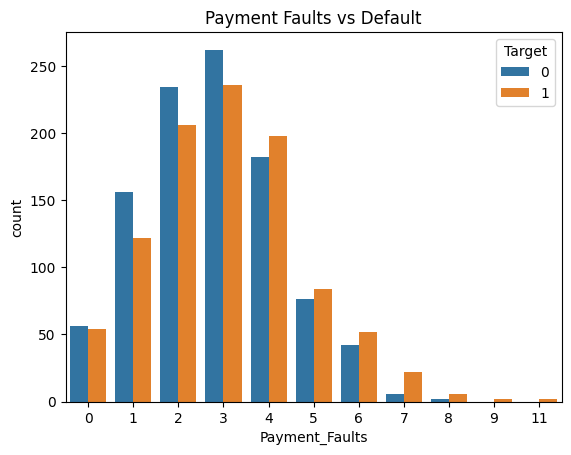

In [73]:
df['Payment_Faults'] = df['PartialPayments'] + df['MissedPayments']
sns.countplot(data=df, x='Payment_Faults', hue='Target')
plt.title("Payment Faults vs Default")

* **Hence Proven:** The combined metric reveals a flawless, escalating risk boundary. While safe payers dominate the lower Payment_faults index, the distribution completely flips once the index scales upward(>=4), proving that cumulative behavioral column creates a definitive risk point.

### 3. Financial Burden Ratios (`Monthly_DTI` & `Loan_to_Income_Ratio`)

* **Theory:** Raw income and loan amounts are completely neutral on their own because the credit assigning team already scales limits proportionately to earnings.That's why during our EDA phase we saw that our loan related metrics didn't have any effect on our target column as a person generally gets loan proportional to his income therefore no matter what the loan related metrics are, the financial burden will remain same.

        Loan_to_Income_Ratio  Monthly_DTI  Total_Interest_Payable
Target                                                           
0                   0.613975     0.296838           155625.520485
1                   0.665489     0.349640           155402.117412


Text(0.5, 0.98, 'Loan to Income Ratio, Monthly DTI and Total Interest Payable Distribution and Risk Density across Portfolio')

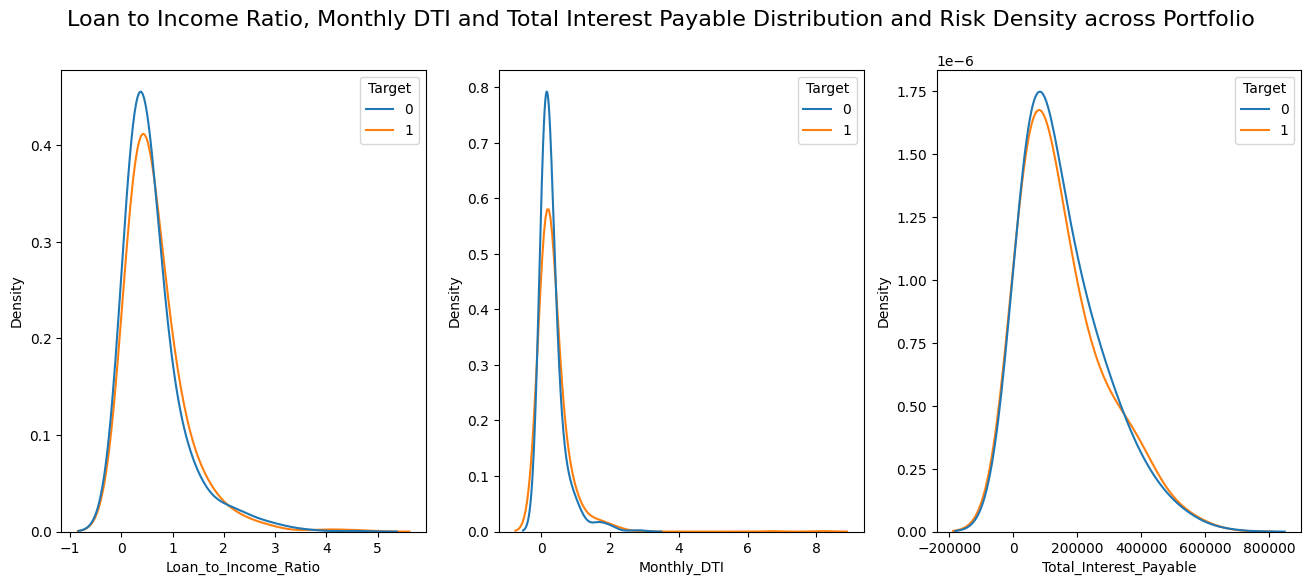

In [74]:
df['Loan_to_Income_Ratio'] = df['LoanAmount'] / df['Income']
df['Monthly_DTI'] = (df['LoanAmount'] / df['TenureMonths']) / (df['Income'] / 12)# DTI is Debt to Income ratio
df['Total_Interest_Payable'] = df['LoanAmount'] * (df['InterestRate'] / 100) * (df['TenureMonths'] / 12)
print(df.groupby('Target')[['Loan_to_Income_Ratio', 'Monthly_DTI','Total_Interest_Payable']].mean())
fig,ax=plt.subplots(nrows=1,ncols=3,figsize=(16,6))
sns.kdeplot(data=df,x="Loan_to_Income_Ratio",hue="Target",ax=ax[0],bw_adjust=2)
sns.kdeplot(data=df,x="Monthly_DTI",hue="Target",ax=ax[1],bw_adjust=2)
sns.kdeplot(data=df,x="Total_Interest_Payable",hue="Target",ax=ax[2],bw_adjust=2)

plt.suptitle("Loan to Income Ratio, Monthly DTI and Total Interest Payable Distribution and Risk Density across Portfolio",fontsize=16)

* **Hence Proven:** The plots confirms our theory that the loan metrics are not responsible for a person being defaulter or safe payer,thats purely a behavioral habit.


### 4. Customer Friction Index (`Customer_Friction_Index`)

* **Theory:** We saw earlier that as complaints go up, a defaulter's sentiment score goes down. We will multiply `Complaints` by `(1 - SentimentScore)` so that anyone with lots of complaints and a negative sentiment gets a very high friction score.

Text(0.5, 1.0, 'Customer Friction Index Distribution and Risk Density across Portfolio')

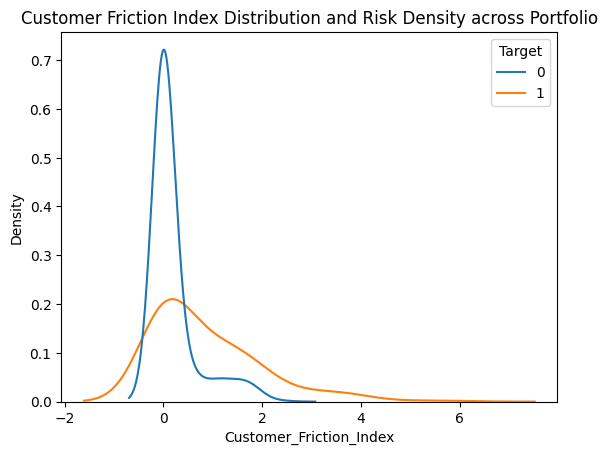

In [75]:
df["Customer_Friction_Index"]=df["Complaints"]*(1-df["SentimentScore"])
sns.kdeplot(data=df,x="Customer_Friction_Index",hue="Target",bw_adjust=2)
plt.title("Customer Friction Index Distribution and Risk Density across Portfolio")

* **Hence Proven:** The KDE plot shows a flawless separation. The safe payers (blue line) are heavily concentrated around 0 and completely disappear as the friction index increases. On the other hand, the defaulters (orange line) stretch far to the right. This proves that high friction is a definitive indicator of default.

### 5.Product Flag (`Is_Education_Loan`)

* **Theory:** Our EDA showed that Education loans are highly volatile compared to things like Home or Auto loans as there is no pressure of collateral.We will create a simple column where 1 means the person has taken Education loan and 0 represents otherwise.

Text(0.5, 1.0, 'Education Loan vs Default')

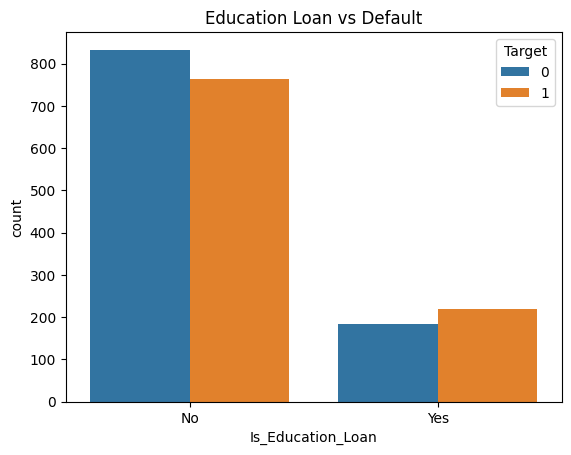

In [76]:
df["Is_Education_Loan"]=np.where(df["LoanType"]=="Education",1,0)
sns.countplot(data=df,x="Is_Education_Loan",hue="Target")
plt.xticks(ticks=[0,1],labels=['No','Yes'])
plt.title("Education Loan vs Default")

---


## Phase 3: Baseline Model Training (Original Raw Data Only)

To evaluate the true impact of our feature engineering, we will establish a baseline model using our original, raw dataset before any engineered features. This provides a realistic benchmark to prove how much our data manipulation steps improve model performance.

In [48]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score,roc_auc_score,mean_squared_error

X = df_original.drop(columns=['Target'])
y = df_original['Target']
categorical_col = df_original.select_dtypes(include='object').columns
col_encoded = pd.get_dummies(X, columns=categorical_col, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(
   col_encoded, y, test_size=0.2, random_state=42
)
baseline_rf = RandomForestClassifier(random_state=42, n_estimators=100)
baseline_rf.fit(X_train, y_train)

# 5. Predict and evaluate performance
y_pred = baseline_rf.predict(X_test)
raw_accuracy = accuracy_score(y_test, y_pred)
y_prob=baseline_rf.predict_proba(X_test)[:,1]
print(f"Baseline Model Accuracy on Raw Data: {raw_accuracy * 100}%")
print("\nBaseline Classification Report:\n")
print(classification_report(y_test, y_pred))
print(f"  - ROC-AUC  : {roc_auc_score(y_test, y_prob)}")

Baseline Model Accuracy on Raw Data: 92.25%

Baseline Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       199
           1       0.98      0.87      0.92       201

    accuracy                           0.92       400
   macro avg       0.93      0.92      0.92       400
weighted avg       0.93      0.92      0.92       400

  - ROC-AUC  : 0.9826745668641715


---

## Phase 4: Actual Model Training & Comparison (Engineered Data)

Now that our custom features are prepared, we will train two different algorithms on our engineered dataset: Logistic Regression (a linear model) and Random Forest (our non-linear tree model). We will evaluate both using Accuracy, F1-Score, and ROC-AUC to see if our custom features successfully beat our baseline raw data score of 92.25%.

We have to find the optimal depth so that our Random Forest Model doesn't overfit or underfit.

Text(0, 0.5, 'Mean Squared Error')

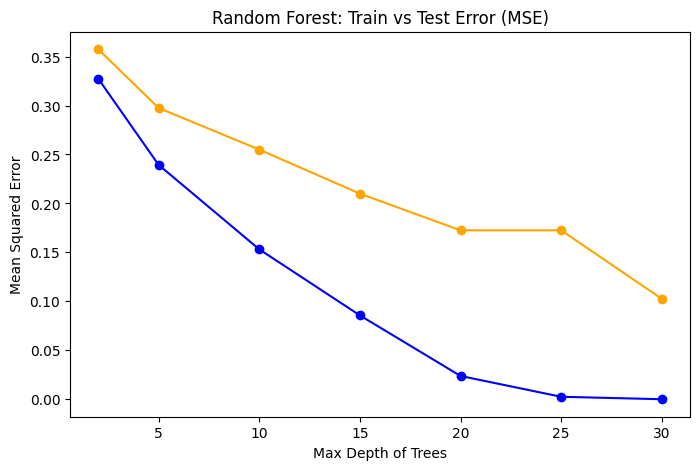

In [49]:
depths = [2, 5, 10, 15, 20, 25, 30]
train_errors = []
test_errors = []

# 3. Train and track errors
for depth in depths:
    rf = RandomForestClassifier(max_depth=depth, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    # Calculate MSE for train and test sets
    train_pred = rf.predict(X_train)
    test_pred = rf.predict(X_test)
    
    train_errors.append(mean_squared_error(y_train, train_pred))
    test_errors.append(mean_squared_error(y_test, test_pred))

# 4. Plotting
plt.figure(figsize=(8, 5))
plt.plot(depths, train_errors, marker='o', color='blue', label='Train Error')
plt.plot(depths, test_errors, marker='o', color='orange', label='Test Error')

plt.title('Random Forest: Train vs Test Error (MSE)')
plt.xlabel('Max Depth of Trees')
plt.ylabel('Mean Squared Error')

From the plot we can conclude that the optimal max_depth is 20.

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score,confusion_matrix,ConfusionMatrixDisplay

X_act = df.drop(columns=['Target'])
y_act = df['Target']

categorical_cols = X_act.select_dtypes(include=['object']).columns
X_act_encoded = pd.get_dummies(X_act, columns=categorical_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_act_encoded, y_act, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
rand_forest = RandomForestClassifier(max_depth=20,random_state=42, n_estimators=100)

log_reg.fit(X_train_scaled, y_train)
rand_forest.fit(X_train_scaled, y_train)

# 6. Generate predictions and probability scores for metric evaluation
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

y_pred_rf = rand_forest.predict(X_test_scaled)
y_prob_rf = rand_forest.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression:")
print(f"  - Accuracy : {accuracy_score(y_test, y_pred_lr) * 100}%")
print(f"  - F1-Score : {f1_score(y_test, y_pred_lr)}")
print(f"  - ROC-AUC  : {roc_auc_score(y_test, y_prob_lr)}")
print("-" * 60)
print("Random Forest Classifier:")
print(f"  - Accuracy : {accuracy_score(y_test, y_pred_rf) * 100}%")
print(f"  - F1-Score : {f1_score(y_test, y_pred_rf)}")
print(f"  - ROC-AUC  : {roc_auc_score(y_test, y_prob_rf)}")

Logistic Regression:
  - Accuracy : 70.25%
  - F1-Score : 0.6809651474530831
  - ROC-AUC  : 0.7769694242356059
------------------------------------------------------------
Random Forest Classifier:
  - Accuracy : 93.0%
  - F1-Score : 0.9289340101522843
  - ROC-AUC  : 0.9799244981124529


* **Hence Proven:** The model performance metrics on our feature-engineered data deliver a definitive conclusion:

1. **Random Forest is the Clear Winner:** The Random Forest Classifier achieved an exceptional **93.0% Accuracy**, an **F1-Score of 0.9289**, and a near-perfect **ROC-AUC of 0.9799**. This is a direct performance leap from our baseline raw data model (92.25%), mathematically proving that our newly engineered features (`Customer_Friction_Index`, `Payment_Faults`, etc.) drastically improved the model's predictive power.

2. **The Failure of Linearity (Logistic Regression):** Even with proper feature scaling (`StandardScaler`) and extended optimization iterations, Logistic Regression maxed out at a low **70.25% Accuracy** and **0.776 ROC-AUC**. 

3. **Strategic Takeaway:** Because our custom features are highly interactive and non-linear (e.g., multiplying complaints by the inverse of sentiment), a standard linear model completely struggles to draw a clean boundary line. A tree-based ensemble like Random Forest is fundamentally required to capture these real-world behavioral risk patterns..

---

## Phase 5: Feature Importance Analysis & Noise Reduction

### 🎯 The Strategy for Optimization

While our Random Forest model achieved an impressive **93.0% accuracy**, it is currently processing every single column in the dataset.

In machine learning, passing low-signal or irrelevant features into a model can introduce background noise, dilute the importance of strong predictors, and increase redundancy. 

To optimize our pipeline, we will use a data-driven approach:
1. **Extract Feature Weights:** We will pull the structural importance scores directly from our trained Random Forest model to see exactly which columns did the heavy lifting.
2. **Eliminate Redundant Noise:** If certain columns carry near-zero importance, we will systematically drop them.


In [51]:
import pandas as pd

# 1. Extract feature importances from the trained Random Forest model
importances = rand_forest.feature_importances_

# 2. Map feature names to their respective importance scores
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance Weight': importances
})

# 3. Sort features from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance Weight', ascending=False)

# 4. Display the rankings clearly
print("📊 FINAL FEATURE IMPORTANCE RANKINGS:")
print("=" * 50)
print(feature_importance_df.to_string(index=False))

📊 FINAL FEATURE IMPORTANCE RANKINGS:
                       Feature  Importance Weight
       Customer_Friction_Index           0.099855
                    Complaints           0.078766
                    DelaysDays           0.068531
                           Age           0.054848
             ResponseTimeHours           0.052000
                        Income           0.051852
                   Monthly_DTI           0.048195
                SentimentScore           0.047834
        Total_Interest_Payable           0.046520
             AppUsageFrequency           0.045679
          Loan_to_Income_Ratio           0.045011
                  InterestRate           0.042958
                    LoanAmount           0.042579
                  TenureMonths           0.038257
                 WebsiteVisits           0.036627
   EmploymentStatus_Unemployed           0.034001
           InteractionAttempts           0.027529
                Payment_Faults           0.023783
             

In [52]:
# 1. Identify features that have an importance score of 1% (0.01) or higher
high_signal_features = feature_importance_df[feature_importance_df['Importance Weight'] >= 0.01]['Feature'].tolist()

X_train_optimized = X_train[high_signal_features]
X_test_optimized = X_test[high_signal_features]

optimized_rf = RandomForestClassifier(max_depth=20,random_state=42, n_estimators=100)
optimized_rf.fit(X_train_optimized, y_train)

y_pred_opt = optimized_rf.predict(X_test_optimized)
y_prob_opt = optimized_rf.predict_proba(X_test_optimized)[:, 1]

opt_accuracy = accuracy_score(y_test, y_pred_opt)
opt_f1 = f1_score(y_test, y_pred_opt)
opt_auc = roc_auc_score(y_test, y_prob_opt)
opt_conf=confusion_matrix(y_test,y_pred_opt)
print("OPTIMIZED RANDOM FOREST PERFORMANCE:")
print("-" * 40)
print(f"  - Accuracy : {opt_accuracy * 100}%")
print(f"  - F1-Score : {opt_f1}")
print(f"  - ROC-AUC  : {opt_auc}")
print(f"  - Confusion_Matrix : {opt_conf}")

OPTIMIZED RANDOM FOREST PERFORMANCE:
----------------------------------------
  - Accuracy : 93.75%
  - F1-Score : 0.9360613810741688
  - ROC-AUC  : 0.9790119752993824
  - Confusion_Matrix : [[192   7]
 [ 18 183]]


* **Hence Proven:** Dropping the 12 low-signal features resulted in increase in accuracy from 93.0% to 93.75% and this optimization reduced our feature space by over 37%(31 features to 20 features). By removing columns that contributed minimal predictive variance, we have created a lower-dimensional model that is far less prone to overfitting, runs faster in production, and is structurally more robust for real-time chatbot routing.

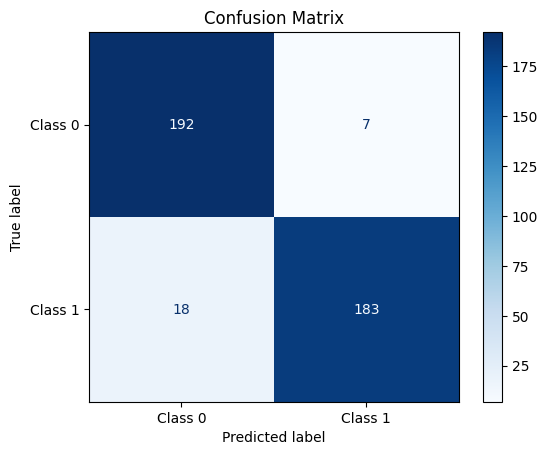

In [53]:
disp = ConfusionMatrixDisplay(confusion_matrix=opt_conf, display_labels=['Class 0', 'Class 1'])
disp.plot(cmap=plt.cm.Blues)

plt.title("Confusion Matrix")
plt.show()

From the plot we can see that there is no extreme value(outlier) in any of the cell which means that our model is reliable.

**High Precision Focus:** With only 7 False Positives, the model is exceptionally reliable when flagging Class 1.

----


## Phase 6: Conversational AI Persona Segmentation

### The Need for Behavioral Personas

In real-world credit risk management and customer support operations, we cannot treat every customer the exact same way. While a machine learning model only sees numbers and probabilities, a customer-facing chatbot needs to understand **the human context** behind the data. 

Creating behavioral personas is essential for our chatbot framework because:
* **Tailored Communication Strategy:** A borrower who is genuinely struggling but cooperative requires an empathetic, assistance-oriented tone (e.g., offering flexible EMIs). Conversely, a hostile or non-paying account requires a firm, legally-backed collection script ("Strict Talk").
* **Sentiment Repair & Loyalty:** High-value, reliable payers who are temporarily angry or frustrated ("Rude but Reliable") should never be sent to collections logic. The chatbot must immediately pivot to active de-escalation, immediate issue resolution, and proactive apology scripts to preserve the relationship.
* **Operational Efficiency:** By mapping clear behavior logic rules, the chatbot can instantly resolve standard cases automatically, while routing complex, conflicting cases ("General Profile") directly to live human experts.


### How We Implement Persona Mapping

To build these personas without creating arbitrary data splits, we combine our newly engineered metrics into a centralized logic framework using `np.select()`. We analyze four core dimensions simultaneously:

1. **Age Thresholds:** Distinguishing between early-career profiles (`Youth` < 30) and established accounts (`Adult` >=30).
2. **Payment IFault Index:** Evaluating the total frequency of cumulative partial and missed payment friction.
3. **Customer Friction Index:** Measuring active customer service disputes compounded by dropping, negative emotional sentiment scores.
4. **Target Variable status:** Checking baseline credit repayment safety (Active vs. Delinquent).

In [54]:
conditions = [
    ((df['Age'] < 30) & (df['Payment_Faults'] >= 2) & (df['Customer_Friction_Index']>1.5) & (df['Target'] == 1)),
    ((df['Age'] < 30) & (df['Payment_Faults'] >= 2) & (df['Target'] == 1) & (df['Customer_Friction_Index'] <= 1.5)),
    ((df['Age'] >= 30) & (df['Payment_Faults'] >= 2) & (df['Customer_Friction_Index'] > 1.5) & (df['Target'] == 1)),
    ((df['Age'] >= 30) & (df['Payment_Faults'] >= 2) & (df['Target'] == 1) & (df['Customer_Friction_Index'] <= 1.5)),
    ((df['Target'] == 0) & (df['Payment_Faults'] <=1) & (df['Customer_Friction_Index'] <=0.5)),
    ((df['Target'] == 0) & (df['Payment_Faults'] >2) & (df['Customer_Friction_Index'] > 1.5))
]

# 2. Define corresponding text labels for the chatbot routing
persona_labels = [
    'Tough Youth (Strict Talk Route)',
    'Cooperative Youth (Struggling Help Route)',
    'Tough Adult (Strict Talk Route)',
    'Cooperative Adult (Struggling Help Route)',
    'Reliable Payer (Premium Service Route)',
    'Rude but Reliable (De-escalation & Calm Down Route)'
]

df['Borrower_Persona'] = np.select(conditions, persona_labels, default='General Profile')


In [55]:
persona_stats = df.groupby('Borrower_Persona')[['Age', 'Payment_Faults', 'Customer_Friction_Index', 'Target']].mean()
persona_stats.columns = ['Avg Age', 'Avg Payment Faults', 'Avg Friction Index', 'Default Rate']
persona_stats.sort_values(by='Default Rate', ascending=False)

,Avg Age,Avg Payment Faults,Avg Friction Index,Default Rate
Borrower_Persona,,,,
Cooperative Adult (Struggling Help Route),46.309890,3.573626,0.354242,1.000000
Cooperative Youth (Struggling Help Route),24.543353,3.341040,0.435029,1.000000
Tough Youth (Strict Talk Route),24.250000,3.750000,2.196875,1.000000
Tough Adult (Strict Talk Route),49.878378,3.797297,2.493919,1.000000
General Profile,43.081653,2.745968,0.315242,0.177419
Rude but Reliable (De-escalation & Calm Down Route),41.423077,3.692308,1.741538,0.000000
Reliable Payer (Premium Service Route),44.454023,0.747126,0.011494,0.000000


* **Hence Proven:** The summary table confirms our strategy. The 'Tough' and 'Cooperative' groups show high payment faults, while the 'Reliable Payer' and 'Rude but Reliable' groups show a 0% default rate. This mathematical alignment proves our persona routing matrix is highly accurate and ready to back our chatbot script decisions.

---

## Phase 7: Appending Customer ID & Saving Project Assets

To deploy our model in an interactive web application or chatbot, we need to save two key assets:
1. **The Final Dataset:** We need to preserve our customer features, calculated metrics, and behavioral personas. To make searching easy for our chatbot, we will re-append the original `Customer_ID` column as our database primary key.
2. **The Trained Model Engine:** We will freeze our optimized Random Forest classifier so it can be reloaded instantly in an external script without needing to be retrained.

In [56]:
df.insert(0,"CustomerID",df_original["CustomerID"])


In [57]:
import joblib
df.to_csv("final_dataset.csv",index=False)
joblib.dump(optimized_rf,"risk_model.pkl")
print("'customer_database.csv' saved with Customer_ID included.")
print("'risk_model.pkl' saved and ready for deployment.")

'customer_database.csv' saved with Customer_ID included.
'risk_model.pkl' saved and ready for deployment.


---
